In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.append('..')
from docx import Document

resume_folder = '../datasets/resume_dataset.csv'  # Path to your docx resumes directory
jobs = pd.read_csv('../datasets/jobs.csv', encoding='latin1')

def read_docx_text(filepath):
    try:
        doc = Document(filepath)
        return "\n".join([para.text for para in doc.paragraphs])
    except Exception as e:
        print(f"Failed to read {filepath}: {e}")
        return ""

records = []
for filename in os.listdir(resume_folder):
    if filename.lower().endswith(('.docx', '.doc')):
        filepath = os.path.join(resume_folder, filename)
        text = read_docx_text(filepath)
        records.append({'filename': filename, 'text': text})

resumes = pd.DataFrame(records)
print("Total resumes loaded:", len(resumes))
print(resumes.head())

Total resumes loaded: 228
                            filename  \
0  Abiral_Pandey_Fullstack_Java.docx   
1              Achyuth Resume_8.docx   
2           Adelina_Erimia_PMP1.docx   
3             Adhi Gopalam - SM.docx   
4                     AjayKumar.docx   

                                                text  
0  Name: Abiral Pandey\nEmail: abiral.pandey88@gm...  
1  Achyuth\n540-999-8048\nachyuth.java88@gmail.co...  
2  Adelina Erimia, PMP, Six Sigma Green Belt, SMC...  
3  Adhi Gopalam\nadhigopalam@gmail.com\n281-212-3...  
4  Ajay Kumar (CSM)\t     \t\t     Email/Skype: a...  


0 missing resumes
count      228.000000
mean     18294.346491
std       7505.320847
min          0.000000
25%      13568.250000
50%      17831.000000
75%      22844.000000
max      51681.000000
Name: text_length, dtype: float64


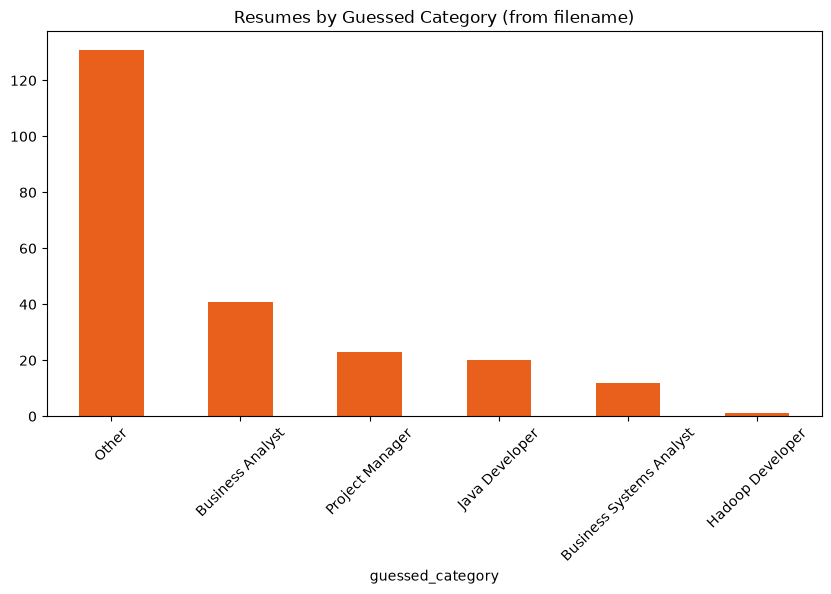

In [95]:
text_col = 'text'

resumes['text_length'] = resumes[text_col].astype(str).apply(len)
print(resumes[text_col].isnull().sum(), "missing resumes")
print(resumes['text_length'].describe())

def guess_category(filename):
    fname = filename.lower()
    if 'ba' in fname or 'business analyst' in fname:
        return 'Business Analyst'
    elif 'java' in fname:
        return 'Java Developer'
    elif 'pm' in fname or 'project manager' in fname or 'scrum' in fname:
        return 'Project Manager'
    elif 'bsa' in fname:
        return 'Business Systems Analyst'
    elif 'hadoop' in fname:
        return 'Hadoop Developer'
    else:
        return 'Other'

resumes['guessed_category'] = resumes['filename'].apply(guess_category)

plt.figure(figsize=(10,5))
resumes['guessed_category'].value_counts().plot(kind='bar', color='#E8601C')
plt.title("Resumes by Guessed Category (from filename)")
plt.xticks(rotation=45)
plt.show()

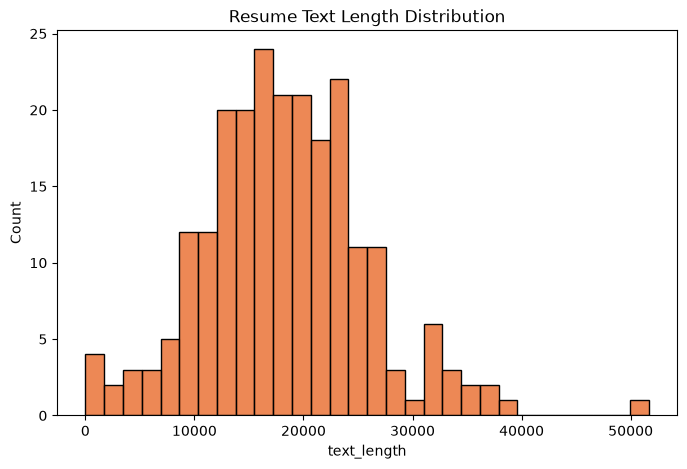

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(resumes['text_length'], bins=30, color='#E8601C')
plt.title("Resume Text Length Distribution")
plt.show()

In [97]:
import importlib
import src.resume_processing.resume_parser as resume_parser_module
importlib.reload(resume_parser_module)

from src.resume_processing.resume_parser import extract_experience, extract_education, extract_education_score

print("extract_experience" in dir(resume_parser_module))

True


In [98]:
from src.skill_extraction import extractor as skill_extractor_module
from src.skill_extraction.extractor import extract_skills
from src.resume_processing.resume_parser import extract_experience, extract_education, extract_education_score

# Injection of permanent path mapping relative to notebooks/ directory
skill_extractor_module.SKILLS_FILE = '../datasets/skills_list.txt'

records = []
for idx, row in resumes.iterrows():
    text = str(row[text_col])
    skills = extract_skills(text)
    exp = extract_experience(text)  # Reverted to strict phrase-matching logic
    edu = extract_education(text)
    edu_score = extract_education_score(edu)
    records.append({
        'resume_id': idx,
        'filename': row['filename'],
        'category': row['guessed_category'],
        'text': text,
        'skills': skills,
        'num_skills': len(skills),
        'experience_years': exp,
        'education_score': edu_score,
        'text_length': len(text)
    })

features_df = pd.DataFrame(records)
print(features_df[['filename', 'num_skills', 'experience_years']].head())

                            filename  num_skills  experience_years
0  Abiral_Pandey_Fullstack_Java.docx          16                 0
1              Achyuth Resume_8.docx          19                 0
2           Adelina_Erimia_PMP1.docx           2                 0
3             Adhi Gopalam - SM.docx           3                12
4                     AjayKumar.docx          10                 0


In [99]:
print(features_df['experience_years'].describe())
print(features_df[features_df['experience_years']==0].shape[0], "resumes still show 0 experience")

count    228.000000
mean       4.214912
std        4.866712
min        0.000000
25%        0.000000
50%        0.000000
75%        8.000000
max       19.000000
Name: experience_years, dtype: float64
120 resumes still show 0 experience


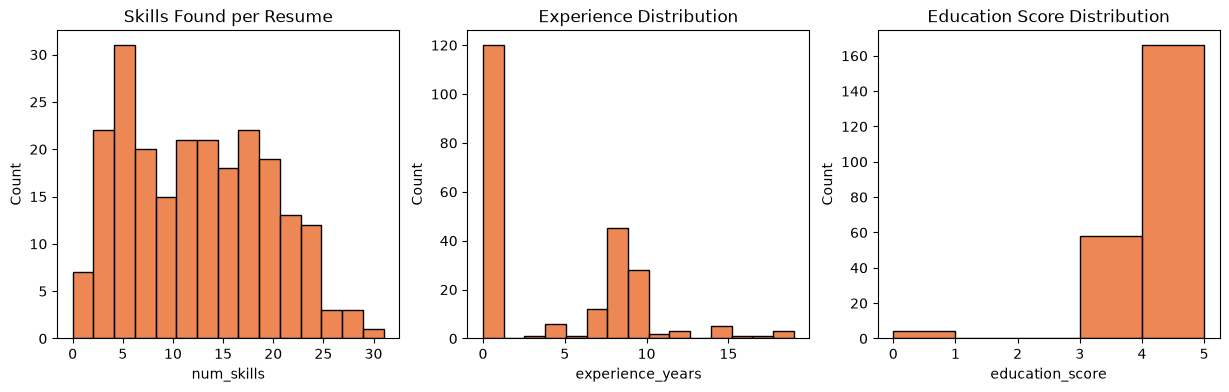

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(features_df['num_skills'], bins=15, ax=axes[0], color='#E8601C')
axes[0].set_title("Skills Found per Resume")
sns.histplot(features_df['experience_years'], bins=15, ax=axes[1], color='#E8601C')
axes[1].set_title("Experience Distribution")
sns.histplot(features_df['education_score'], bins=5, ax=axes[2], color='#E8601C')
axes[2].set_title("Education Score Distribution")
plt.show()

In [101]:
features_df['raw_score'] = (
    features_df['num_skills']*0.4 +
    features_df['experience_years'].clip(0,10)*0.4 +
    features_df['education_score']*0.2
)
threshold = features_df['raw_score'].quantile(0.6)
features_df['label'] = (features_df['raw_score'] >= threshold).astype(int)
print(features_df['label'].value_counts())

label
0    133
1     95
Name: count, dtype: int64


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = features_df[['num_skills', 'experience_years', 'education_score', 'text_length']]
y = features_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df

c:\Users\anuri\Desktop\AI-Hiring-Assistant\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1
Logistic Regression,0.956522,0.904762,1.000000,0.950000
Random Forest,0.934783,0.900000,0.947368,0.923077
XGBoost,0.978261,1.000000,0.947368,0.972973


Best model: XGBoost


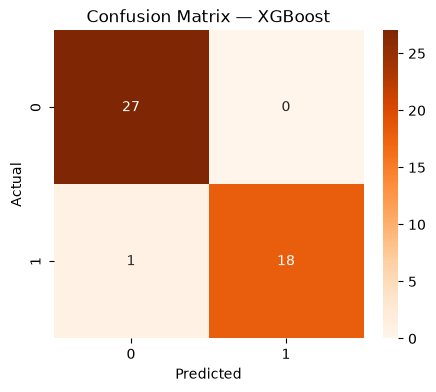

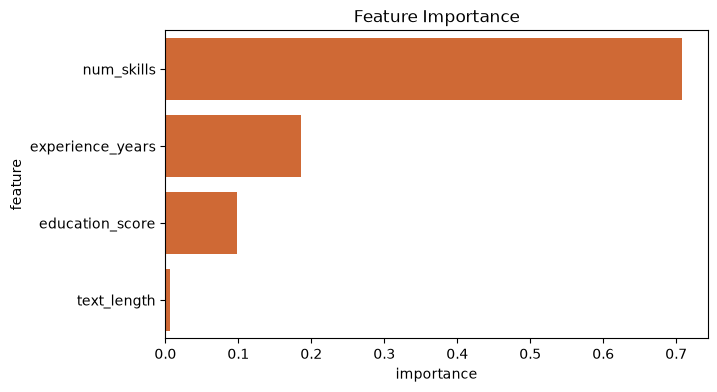

In [103]:
best_name = results_df['f1'].idxmax()
best_model = models[best_name]
print("Best model:", best_name)

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_}).sort_values('importance', ascending=False)
    plt.figure(figsize=(7,4))
    sns.barplot(data=fi, x='importance', y='feature', color='#E8601C')
    plt.title("Feature Importance")
    plt.show()

In [104]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

sbert = SentenceTransformer('all-MiniLM-L6-v2')

job_skill_col = 'Required Skills & Qualifications'  # Matches your jobs.csv column
job_texts = jobs[job_skill_col].astype(str).tolist()
job_embeddings = sbert.encode(job_texts)

# Test on a sample of 20 candidates
sample = features_df.sample(20, random_state=1).copy()
candidate_texts = [", ".join(s) if s else "no skills" for s in sample['skills']]
candidate_embeddings = sbert.encode(candidate_texts)

match_scores = cosine_similarity(candidate_embeddings, job_embeddings)
sample['best_job_match_pct'] = (match_scores.max(axis=1) * 100).round(1)
sample['best_job_title'] = [jobs.iloc[match_scores[i].argmax()]['Job Title'] for i in range(len(sample))]

sample[['resume_id', 'category', 'best_job_title', 'best_job_match_pct']]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,resume_id,category,best_job_title,best_job_match_pct
39,39,Other,Healthcare Data Analyst,39.099998
169,169,Other,DevOps Engineer,58.700001
93,93,Business Analyst,Backend Engineer,51.900002
62,62,Project Manager,Data & Analytics Consultant,39.299999
198,198,Other,DevOps Engineer,61.400002
114,114,Project Manager,Backend Engineer,54.200001
38,38,Other,DevOps Engineer,37.000000
123,123,Other,DevOps Engineer,46.700001
106,106,Other,Backend Engineer,64.099998
89,89,Business Analyst,Healthcare Data Analyst,41.599998


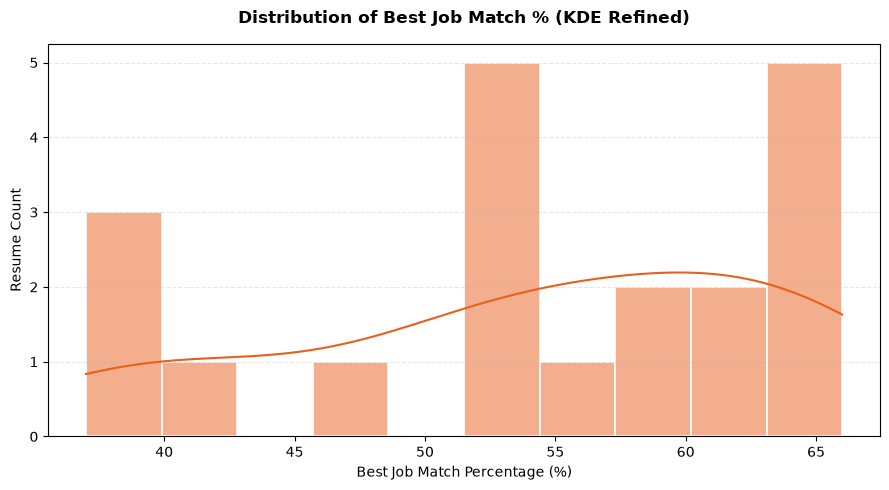

In [105]:
plt.figure(figsize=(9, 5))
# Combining the histogram bars with a smooth density estimation line
sns.histplot(sample['best_job_match_pct'], bins=10, kde=True, color='#E8601C', edgecolor='white', linewidth=1.2)

plt.title("Distribution of Best Job Match % (KDE Refined)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Best Job Match Percentage (%)", fontsize=10)
plt.ylabel("Resume Count", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

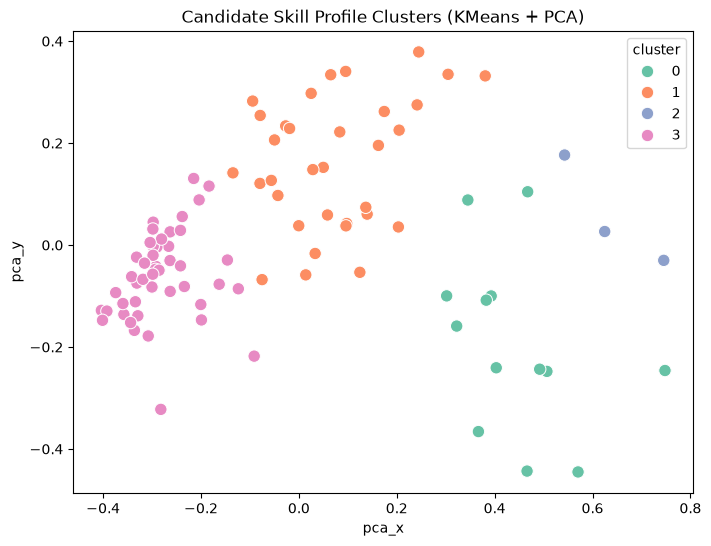

Cluster 0: top skills = ['R', 'SQL', 'Excel', 'SAS', 'Java']
Cluster 1: top skills = ['R', 'SQL', 'Java', 'Excel', 'HTML']
Cluster 2: top skills = ['SQL', 'R', 'Excel', 'Regression', 'Statistics']
Cluster 3: top skills = ['SQL', 'Java', 'R', 'Git', 'HTML']


In [106]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_sample = features_df.sample(100, random_state=3).copy()
cluster_texts = [", ".join(s) if s else "no skills" for s in cluster_sample['skills']]
cluster_embeddings = sbert.encode(cluster_texts)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_sample['cluster'] = kmeans.fit_predict(cluster_embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(cluster_embeddings)
cluster_sample['pca_x'] = coords[:,0]
cluster_sample['pca_y'] = coords[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=cluster_sample, x='pca_x', y='pca_y', hue='cluster', palette='Set2', s=80)
plt.title("Candidate Skill Profile Clusters (KMeans + PCA)")
plt.show()

# Interpret each cluster's linguistic properties
for c in sorted(cluster_sample['cluster'].unique()):
    cluster_skills = []
    for s in cluster_sample[cluster_sample['cluster']==c]['skills']:
        cluster_skills.extend(s)
    from collections import Counter
    top_skills = [s[0] for s in Counter(cluster_skills).most_common(5)]
    print(f"Cluster {c}: top skills = {top_skills}")

   cluster  num_skills  experience_years  education_score
0        0    4.285714          3.857143         3.571429
1        1    9.911765          4.205882         3.588235
2        2    4.333333          3.833333         3.000000
3        3   19.043478          4.652174         3.978261


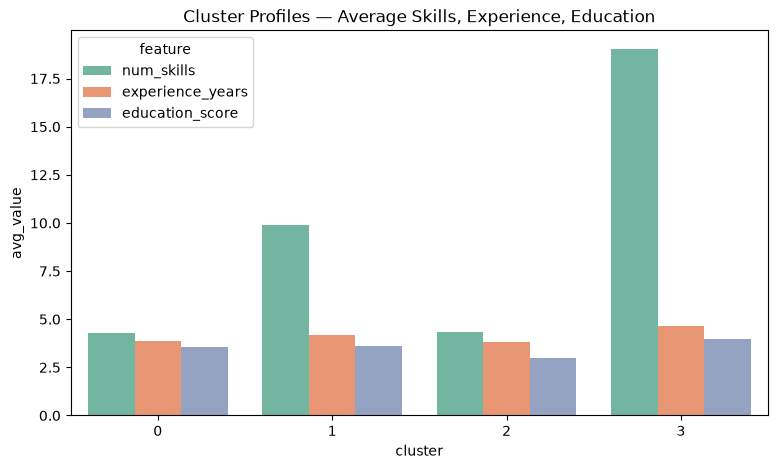

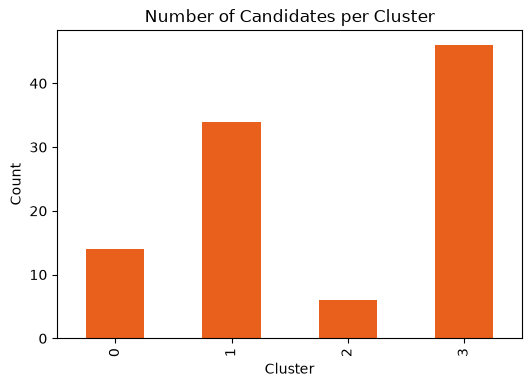

In [107]:
profile = cluster_sample.groupby('cluster')[['num_skills', 'experience_years', 'education_score']].mean().reset_index()
print(profile)

profile_melted = profile.melt(id_vars='cluster', var_name='feature', value_name='avg_value')

plt.figure(figsize=(9,5))
sns.barplot(data=profile_melted, x='cluster', y='avg_value', hue='feature', palette='Set2')
plt.title("Cluster Profiles — Average Skills, Experience, Education")
plt.show()

plt.figure(figsize=(6,4))
cluster_sample['cluster'].value_counts().sort_index().plot(kind='bar', color='#E8601C')
plt.title("Number of Candidates per Cluster")
plt.xlabel("Cluster"); plt.ylabel("Count")
plt.show()

profile.to_csv('../data/processed/cluster_profile.csv', index=False)

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer

sample_texts = features_df['text'].sample(50, random_state=2).tolist()
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(sample_texts)

similarity_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(similarity_matrix, 0)  # Self-similarity isolation
max_similarities = similarity_matrix.max(axis=1) * 100

suspicious_count = (max_similarities > 85).sum()
print(f"Suspicious near-duplicate resumes found: {suspicious_count} out of {len(sample_texts)}")

Suspicious near-duplicate resumes found: 17 out of 50


In [109]:
import joblib
import json

os.makedirs('../models/ranking_model', exist_ok=True)
joblib.dump(best_model, '../models/ranking_model/candidate_ranker.pkl')
joblib.dump(sbert, '../models/ranking_model/sbert_model.pkl')

# Clear out raw text to keep deployment data tables lightweight
features_df.drop(columns=['text']).to_csv('../data/processed/feature_table.csv', index=False)

with open('../data/processed/model_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

if hasattr(best_model, 'feature_importances_'):
    fi.to_csv('../data/processed/feature_importance.csv', index=False)

pd.DataFrame(cm).to_csv('../data/processed/confusion_matrix.csv', index=False)
sample[['resume_id','category','best_job_title','best_job_match_pct']].to_csv('../data/processed/job_match_samples.csv', index=False)
pd.DataFrame({'max_similarity': max_similarities}).to_csv('../data/processed/fraud_similarity_scores.csv', index=False)
cluster_sample[['resume_id','category','cluster','pca_x','pca_y']].to_csv('../data/processed/cluster_results.csv', index=False)
jobs.to_csv('../data/processed/jobs_clean.csv', index=False)

print("ALL ARTIFACTS SAVED — Data Science pipeline complete!")

ALL ARTIFACTS SAVED — Data Science pipeline complete!
